### Data Loading

In [29]:
import pandas as pd
data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(data_url , sep=";")
features = df.drop("quality",axis=1)
label = df["quality"].copy()

### Data Preperation

In [30]:
from sklearn.model_selection import StratifiedShuffleSplit

# Stratifing Whole(Train,Test) DataSet
split = StratifiedShuffleSplit(n_splits=1 , test_size=0.2 , random_state=42)
for train_index , test_index in split.split(features,label):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

# Training DataSet
strat_feat_train = strat_train_set.drop("quality" , axis=1)
strat_label_train = strat_train_set["quality"].copy()

# Test DataSet
strat_feat_test = strat_test_set.drop("quality" , axis=1)
strat_label_test = strat_test_set["quality"].copy()

# Transform Features

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

transform_pipeline = Pipeline([
    ("Imputer" , SimpleImputer(strategy="median")),
    ("std_scaler" , StandardScaler())
])

feat_train = transform_pipeline.fit_transform(strat_feat_train)
feat_test = transform_pipeline.transform(strat_feat_test)



### Model Training

In [31]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(feat_train , strat_label_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

### Evaluate Performance of model onto Training and Test DataSet

In [32]:
from sklearn.metrics import mean_squared_error


# On Training Dataset
pred_train = tree_reg.predict(feat_train)
MSE_TRAIN = mean_squared_error(pred_train , strat_label_train)
print(f"MSE Of Training Dataset: {MSE_TRAIN}")

# On Test Dataset
pred_test = tree_reg.predict(feat_test)
MSE_TEST = mean_squared_error(pred_test , strat_label_test)
print(f"MSE Of Training Dataset: {MSE_TEST}")

MSE Of Training Dataset: 0.0
MSE Of Training Dataset: 0.55625


### Visualization

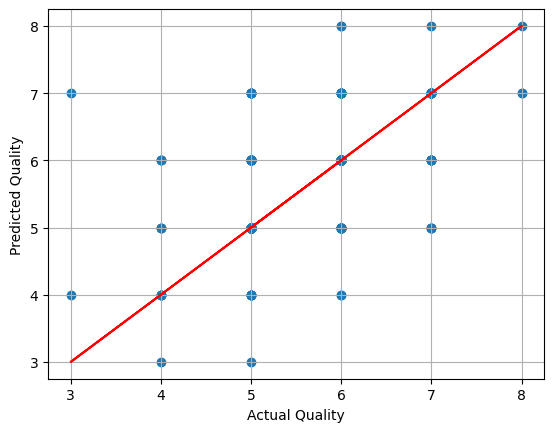

In [33]:
import matplotlib.pyplot as plt
plt.scatter(strat_label_test , pred_test)
plt.plot(strat_label_test , strat_label_test , "r-")
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.grid(True)